In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "src")))
# Or if running from root:
sys.path.append(os.path.abspath(os.getcwd()))

from src.config import DataConfig
from src.datasets.data import SpectroscopicDataset
from src.datasets.dataloader import get_dataloader

# Config paths
DATA_DIR = DataConfig.DATA_DIR
SIMILARITY_INDEX_PATH = DataConfig.SIMILARITY_INDEX_PATH
SMILES_VOCAB_PATH = DataConfig.SMILES_VOCAB_PATH

print("Initializing Dataset...")
dataset = SpectroscopicDataset(DATA_DIR, SIMILARITY_INDEX_PATH, SMILES_VOCAB_PATH)
print(f"Component k range: {dataset.min_k} to {dataset.max_k},distribution:{dataset.k_distribution}")
print(f"Dataset Weight Distribution: {dataset.weight_distribution}")

print("Creating DataLoader...")
loader = get_dataloader(dataset, batch_size=128, shuffle=True, num_workers=4)

# # Iterate through batches and visualize
# for batch_idx, batch in enumerate(loader):
#     if batch_idx >= 10:
#         break
        
#     # Pick the first sample from each batch
#     idx = 0
#     mixture = batch['mixture_spectra'][idx].numpy()
#     components = batch['component_spectra'][idx].numpy()
#     weights = batch['component_weights'][idx].numpy()
#     mask = batch['component_mask'][idx].numpy()
#     num_comps = batch['num_components'][idx].item()
    
#     print(f"Processing Batch {batch_idx}, Sample {idx}")
#     print(f"  Number of components: {num_comps}")
#     print(f"  Weights: {weights[mask]}")
    
#     # Plotting
#     fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
#     # 1. Mixture Spectrum
#     axes[0].plot(mixture, color='black', linewidth=2, label='Mixture (Normalized)')
#     axes[0].set_title(f"Batch {batch_idx} - Sample {idx} (Num Components: {num_comps})")
#     axes[0].set_ylabel("Intensity")
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.3)
    
#     # 2. Component Spectra
#     # Only plot valid components (where mask is True)
#     for i in range(len(mask)):
#         if mask[i]:
#             weight = weights[i]
#             # Plot weighted component
#             axes[1].plot(components[i] * weight, label=f"Comp {i+1} (w={weight:.2f})", alpha=0.8)
            
#     axes[1].set_title("Component Spectra (Weighted Contribution)")
#     axes[1].set_xlabel("Spectral Point Index")
#     axes[1].set_ylabel("Intensity")
#     axes[1].legend()
#     axes[1].grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()


/home/gaohanyu/miniconda3/envs/mixture/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing Dataset...
Component k range: 2 to 6,distribution:chi-squared
Dataset Weight Distribution: random
Creating DataLoader...


In [2]:
from src.datasets.data import SpectroscopicDataset

dataset = SpectroscopicDataset(
    data_dir=DATA_DIR,
    similarity_index_path=SIMILARITY_INDEX_PATH,
    smiles_vocab_path=SMILES_VOCAB_PATH
)

item = dataset[0]
# Check if item is a list (Dynamic Mixing enabled) or a dict
if isinstance(item, list):
    print(f"Item is a list with {len(item)} components (Dynamic Mixing enabled).")
    print("Keys of the first component:", item[0].keys())
else:
    print(item.keys())

Item is a list with 4 components (Dynamic Mixing enabled).
Keys of the first component: dict_keys(['data', 'global_id', 'tokenized_smiles', 'weight', 'is_anchor', 'normalized_ir'])


In [3]:
from src.config import DataConfig, GlobalConfig
from src.datasets.data import SpectroscopicDataset
import numpy as np

# Config paths
DATA_DIR = DataConfig.DATA_DIR
SIMILARITY_INDEX_PATH = DataConfig.SIMILARITY_INDEX_PATH
SMILES_VOCAB_PATH = DataConfig.SMILES_VOCAB_PATH

print("Initializing Full Dataset to determine size...")
full_dataset = SpectroscopicDataset(DATA_DIR, SIMILARITY_INDEX_PATH, SMILES_VOCAB_PATH)
total_size = len(full_dataset)
print(f"Total dataset size: {total_size}")

# Split Indices
print("Splitting indices...")
train_indices, val_indices, test_indices = SpectroscopicDataset.split_indices(
    total_size, 
    train_ratio=DataConfig.TRAIN_RATIO, 
    val_ratio=DataConfig.VAL_RATIO, 
    test_ratio=DataConfig.TEST_RATIO,
    seed=GlobalConfig.SEED
)

print(f"Train indices: {len(train_indices)} ({len(train_indices)/total_size:.2%})")
print(f"Val indices:   {len(val_indices)} ({len(val_indices)/total_size:.2%})")
print(f"Test indices:  {len(test_indices)} ({len(test_indices)/total_size:.2%})")

# Instantiate Datasets
# Reuse the underlying HF dataset to save memory/time
shared_hf_dataset = full_dataset.dataset

print("\nInitializing Split Datasets...")
train_dataset = SpectroscopicDataset(DATA_DIR, SIMILARITY_INDEX_PATH, SMILES_VOCAB_PATH, indices=train_indices, preloaded_dataset=shared_hf_dataset)
val_dataset = SpectroscopicDataset(DATA_DIR, SIMILARITY_INDEX_PATH, SMILES_VOCAB_PATH, indices=val_indices, preloaded_dataset=shared_hf_dataset)
test_dataset = SpectroscopicDataset(DATA_DIR, SIMILARITY_INDEX_PATH, SMILES_VOCAB_PATH, indices=test_indices, preloaded_dataset=shared_hf_dataset)

print(f"Train Dataset: {len(train_dataset)} samples")
print(f"Val Dataset:   {len(val_dataset)} samples")
print(f"Test Dataset:  {len(test_dataset)} samples")

# Optional: Check for overlap
print("\nChecking for index overlap...")
train_set = set(train_indices)
val_set = set(val_indices)
test_set = set(test_indices)

overlap_tv = train_set.intersection(val_set)
overlap_vt = val_set.intersection(test_set)
overlap_tt = train_set.intersection(test_set)

print(f"Train-Val Overlap: {len(overlap_tv)}")
print(f"Val-Test Overlap:  {len(overlap_vt)}")
print(f"Train-Test Overlap: {len(overlap_tt)}")

Initializing Full Dataset to determine size...
Total dataset size: 794386
Splitting indices...
Train indices: 635508 (80.00%)
Val indices:   79439 (10.00%)
Test indices:  79439 (10.00%)

Initializing Split Datasets...
Train Dataset: 635508 samples
Val Dataset:   79439 samples
Test Dataset:  79439 samples

Checking for index overlap...
Train-Val Overlap: 0
Val-Test Overlap:  0
Train-Test Overlap: 0


Analyzing Train (FULL dataset: 635508 items)...


Analyzing Train: 100%|██████████| 635508/635508 [00:52<00:00, 12152.81it/s]


Analyzing Val (FULL dataset: 79439 items)...


Analyzing Val: 100%|██████████| 79439/79439 [00:05<00:00, 14048.09it/s]


Analyzing Test (FULL dataset: 79439 items)...


Analyzing Test: 100%|██████████| 79439/79439 [00:08<00:00, 9090.57it/s] 


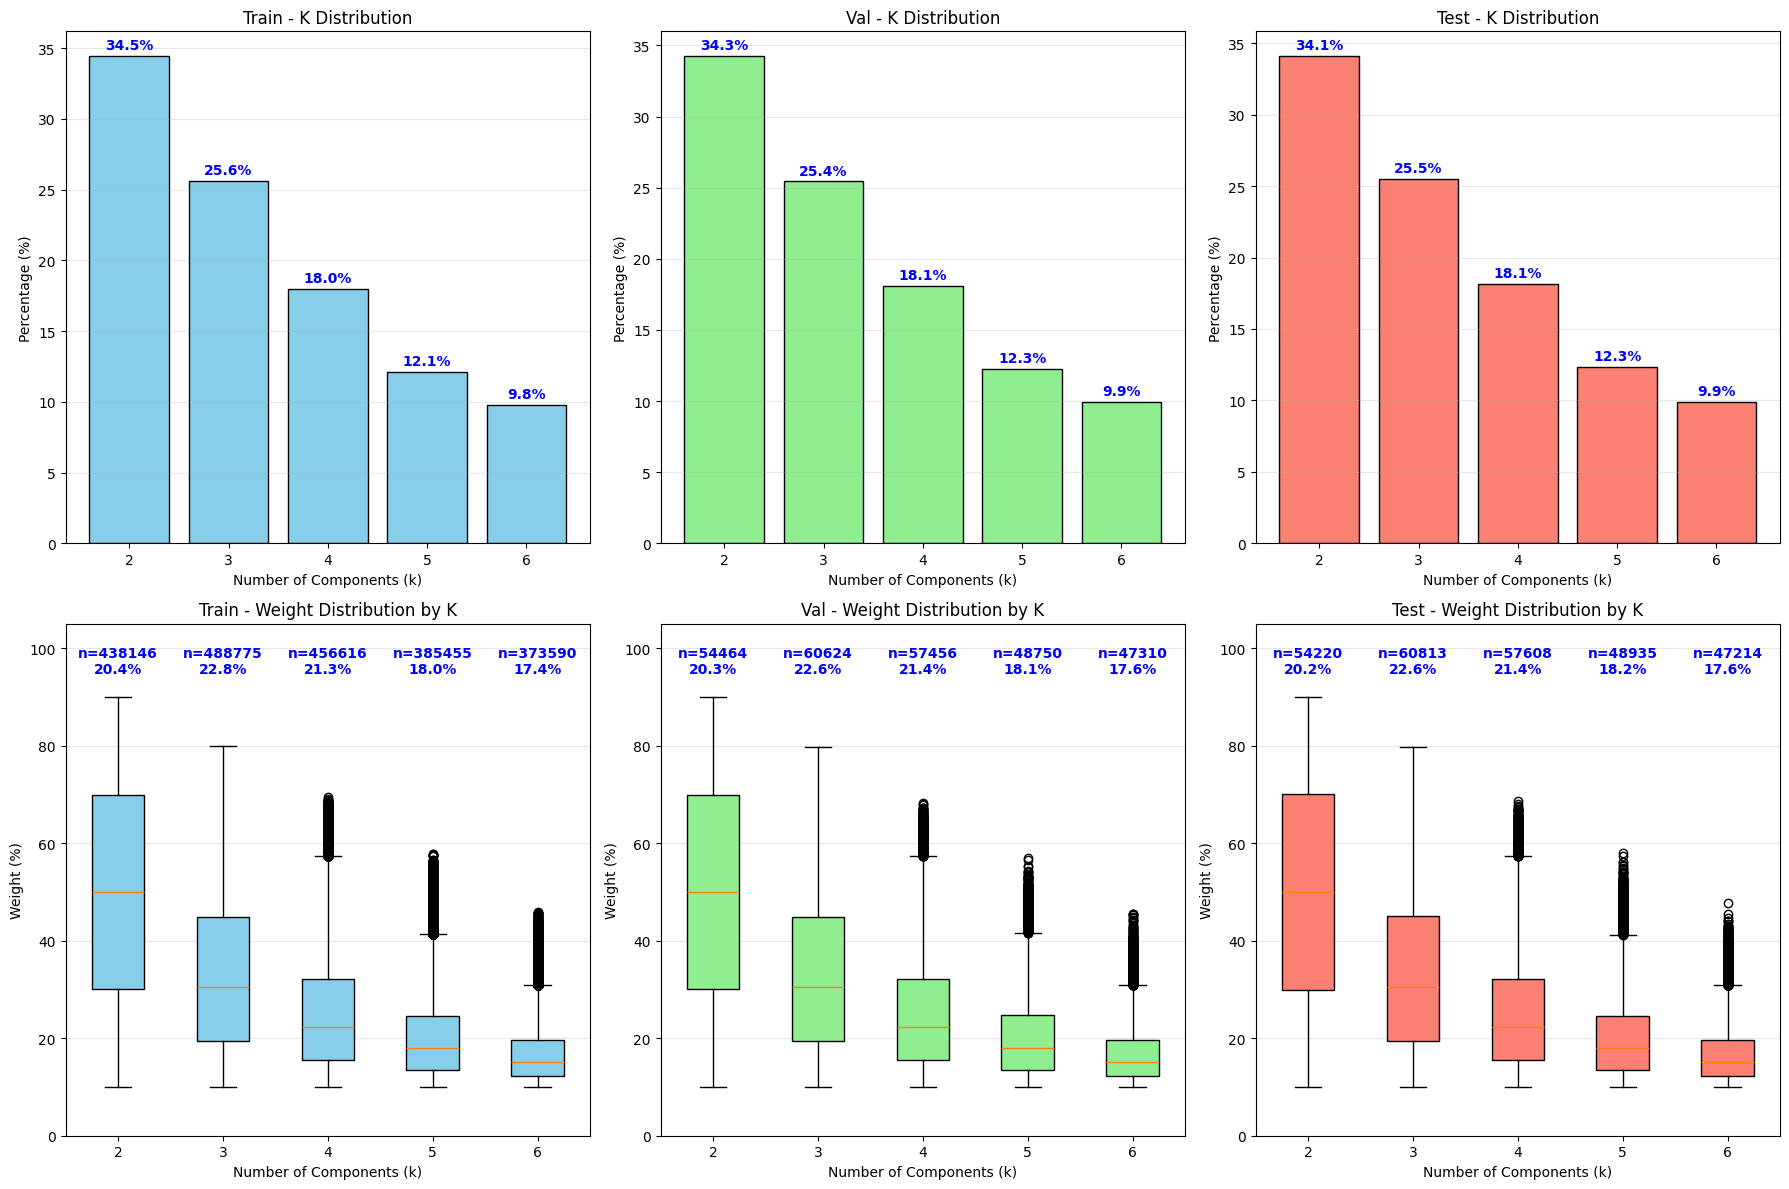

In [4]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

def analyze_distribution(dataset, name="Dataset", num_samples=None):
    # Returns list of tuples: (k, [weights])
    data_points = []
    total_len = len(dataset)
    if num_samples is None or num_samples == "all":
        print(f"Analyzing {name} (FULL dataset: {total_len} items)...")
        indices = range(total_len)
    else:
        print(f"Analyzing {name} (sampling {num_samples} items)...")
        actual_samples = min(total_len, num_samples)
        indices = np.random.choice(total_len, actual_samples, replace=False)
    is_dynamic = getattr(dataset, 'dynamic_mixing', False)
    for idx in tqdm(indices, desc=f"Analyzing {name}"):
        try:
            global_idx = int(dataset.indices[idx])
            if is_dynamic:
                plan = dataset.get_mixing_plan(global_idx)
                k = len(plan)
                weights = [item['weight'] for item in plan]
                data_points.append((k, weights))
            else:
                data_points.append((1, [1.0]))
        except Exception as e:
            pass
    return data_points

# Analyze
datasets = [("Train", analyze_distribution(train_dataset, "Train", num_samples="all")),
            ("Val", analyze_distribution(val_dataset, "Val", num_samples="all")),
            ("Test", analyze_distribution(test_dataset, "Test", num_samples="all"))]

def get_k_list(data):
    return [d[0] for d in data]

def get_weights_by_k(data):
    weights_by_k = {}
    for k, w_list in data:
        if k not in weights_by_k:
            weights_by_k[k] = []
        weights_by_k[k].extend(w_list)
    return weights_by_k

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

def get_weights_for_hist(data):
    return np.ones_like(data) / len(data) * 100

# --- Row 1: K Distribution (Histogram) ---
all_ks = []
for _, d in datasets:
    all_ks.extend(get_k_list(d))
if all_ks:
    min_k = min(all_ks)
    max_k = max(all_ks)
    bins_k = np.arange(min_k, max_k + 2) - 0.5
    xticks = range(min_k, max_k + 1)
else:
    bins_k = 10
    xticks = []

for i, (name, data) in enumerate(datasets):
    k_list = get_k_list(data)
    ax = axes[0, i]
    n, bins, patches = ax.hist(k_list, bins=bins_k, weights=get_weights_for_hist(k_list), rwidth=0.8, color=['skyblue', 'lightgreen', 'salmon'][i], edgecolor='black')
    ax.set_title(f"{name} - K Distribution")
    ax.set_xticks(xticks)
    ax.set_xlabel("Number of Components (k)")
    ax.set_ylabel("Percentage (%)")
    ax.grid(axis='y', alpha=0.3)
    # 标注每个k的实际百分比
    total = len(k_list)
    for j, k in enumerate(xticks):
        count = np.sum(np.array(k_list) == k)
        percent = count / total * 100 if total > 0 else 0
        ax.annotate(f"{percent:.1f}%", xy=(k, percent), xytext=(0, 5), textcoords='offset points', ha='center', color='blue', fontsize=10, fontweight='bold')

# --- Row 2: Weight Distribution (Box Plot by K) ---
for i, (name, data) in enumerate(datasets):
    w_by_k = get_weights_by_k(data)
    sorted_ks = sorted(w_by_k.keys())
    plot_data = [np.array(w_by_k[k]) * 100 for k in sorted_ks]
    ax = axes[1, i]
    parts = ax.boxplot(plot_data, tick_labels=sorted_ks, patch_artist=True)
    color = ['skyblue', 'lightgreen', 'salmon'][i]
    for box in parts['boxes']:
        box.set_facecolor(color)
    # 标注每个k的样本数和占比
    total = sum(len(w_by_k[k]) for k in sorted_ks)
    for j, k in enumerate(sorted_ks):
        n_k = len(w_by_k[k])
        percent = n_k / total * 100 if total > 0 else 0
        ax.annotate(f"n={n_k}\n{percent:.1f}%", xy=(j+1, 100), xytext=(0, -18), textcoords='offset points', ha='center', color='blue', fontsize=10, fontweight='bold')
    ax.set_title(f"{name} - Weight Distribution by K")
    ax.set_xlabel("Number of Components (k)")
    ax.set_ylabel("Weight (%)")
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
from src.config import DataConfig
from src.datasets.data import SpectroscopicDataset
from src.datasets.dataloader import get_dataloader
import torch

# 1. Initialize Dataset and DataLoader
dataset = SpectroscopicDataset(
    data_dir=DataConfig.DATA_DIR,
    similarity_index_path=DataConfig.SIMILARITY_INDEX_PATH,
    smiles_vocab_path=DataConfig.SMILES_VOCAB_PATH,
)
# shuffle=False ensures we get the first batch deterministically (though contents are random due to dynamic mixing)
dataloader = get_dataloader(dataset, batch_size=128, shuffle=False)

# 2. Fetch one batch
batch = next(iter(dataloader))

# --- Added: Inspect Batch Format ---
print(f"=== Batch Data Format (Batch Size: {batch['mixture_spectra'].shape[0]}) ===")
for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(f"Key: {key:<25} | Type: {str(value.dtype):<15} | Shape: {value.shape}")
    else:
        print(f"Key: {key:<25} | Type: {type(value)} | Value: {value}")
print("\n")
# -----------------------------------

# 3. Helper function to decode SMILES tokens back to string
vocab = dataset.smiles_vocab
itos = {i: c for c, i in vocab.items()}
pad_idx = vocab.get("<pad>", 0)

def decode_smiles(token_ids):
    chars = []
    for tid in token_ids:
        tid = tid.item()
        if tid == pad_idx:
            continue
        # Stop at end token if exists, or just ignore padding
        chars.append(itos.get(tid, ""))
    return "".join(chars)

# 4. Inspect the first sample in the batch
idx = 0
num_comps = batch['num_components'][idx].item()

print(f"=== Inspecting Batch Sample {idx} ===")
print(f"Number of Components: {num_comps}")

# --- SMILES ---
print("\n[SMILES Content in Batch]")
smiles_tensor = batch['smiles'][idx]  # Shape: (Max_K, Max_Len)
weights = batch['component_weights'][idx] # Shape: (Max_K,)

for k in range(num_comps):
    s_str = decode_smiles(smiles_tensor[k])
    w = weights[k].item()
    print(f"  Component {k} (Weight={w:.4f}): {s_str}")

# --- IR Spectra ---
print("\n[IR Spectra Content in Batch (First 10 points)]")
# Mixture Spectrum
mix_spec = batch['mixture_spectra'][idx]
print(f"  Mixture Spectrum: {mix_spec[:10].tolist()}")

# Component Spectra
comp_specs = batch['component_spectra'][idx]
for k in range(num_comps):
    print(f"  Component {k} Spectrum: {comp_specs[k][:10].tolist()}")

print("\nNote: These values are exactly what the model receives in this batch.")

=== Batch Data Format (Batch Size: 128) ===
Key: mixture_spectra           | Type: torch.float32   | Shape: torch.Size([128, 1800])
Key: component_spectra         | Type: torch.float32   | Shape: torch.Size([128, 6, 1800])
Key: component_weights         | Type: torch.float32   | Shape: torch.Size([128, 6])
Key: component_mask            | Type: torch.bool      | Shape: torch.Size([128, 6])
Key: is_anchor                 | Type: torch.bool      | Shape: torch.Size([128, 6])
Key: smiles                    | Type: torch.int64     | Shape: torch.Size([128, 6, 128])
Key: num_components            | Type: torch.int64     | Shape: torch.Size([128])


=== Inspecting Batch Sample 0 ===
Number of Components: 2

[SMILES Content in Batch]
  Component 0 (Weight=0.2758): COC(=O)[C@@H]1CC[C@H]1CNC(=O)OC(C)(C)C
  Component 1 (Weight=0.7242): COc1nc2ccccc2cc1C(=O)O

[IR Spectra Content in Batch (First 10 points)]
  Mixture Spectrum: [0.027059467509388924, 0.0558035708963871, 0.012834821827709675, 0.040

In [ ]:
import os
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

# 1. Check raw file size
raw_file = "/data0/gaohanyu/data/raw_data/multimodal_spectroscopic_dataset/aligned_chunk_0.parquet"

# 2. Load with pandas
try:
    print(f"Reading {raw_file}...")
    df = pd.read_parquet(raw_file)
    row = df.iloc[0]
    
    print("\n=== Column Size Contribution Analysis ===")
    
    # Define groups
    groups = {
        "HSQC (2D Matrix)": ['hsqc_nmr_spectrum'],
        "1D Spectra (IR, H-NMR, C-NMR)": ['ir_spectra', 'h_nmr_spectra', 'c_nmr_spectra'],
        "MSMS (Mass Spec)": [c for c in df.columns if 'msms' in c],
        "Metadata (SMILES, Peaks, etc)": [c for c in df.columns if 'msms' not in c and 'spectra' not in c and 'spectrum' not in c]
    }
    
    total_row_size = 0
    group_sizes = {}
    
    for group_name, cols in groups.items():
        group_size = 0
        for col in cols:
            if col not in df.columns: continue
            val = row[col]
            
            # Calculate size
            if isinstance(val, np.ndarray):
                # Check for object arrays (like list of lists) or numeric arrays
                if val.dtype == 'O' and len(val) > 0 and isinstance(val[0], np.ndarray):
                     # Recursive size for array of arrays (like HSQC sometimes loaded)
                     size = sum(sub.nbytes for sub in val)
                else:
                    size = val.nbytes
            elif isinstance(val, str):
                size = len(val.encode('utf-8'))
            elif isinstance(val, (int, float)):
                size = 8
            else:
                size = 0 # Ignore small metadata overhead
                
            group_size += size
            
        group_sizes[group_name] = group_size
        total_row_size += group_size

    # Print Report
    print(f"{'Group':<35} | {'Size/Row':<12} | {'% of Total':<10} | {'Est. Chunk Size (3200 rows)'}")
    print("-" * 90)
    for name, size in group_sizes.items():
        percent = (size / total_row_size * 100) if total_row_size > 0 else 0
        chunk_gb = (size * 3200) / (1024**3)
        print(f"{name:<35} | {size/(1024**2):.2f} MB    | {percent:.1f}%      | {chunk_gb:.4f} GB")
    
    print("-" * 90)
    print(f"Total per Row: {total_row_size/(1024**2):.2f} MB")
    print(f"Total Chunk Size: {(total_row_size * 3200) / (1024**3):.4f} GB")
    
    print("\nConclusion:")
    if group_sizes["HSQC (2D Matrix)"] > group_sizes["1D Spectra (IR, H-NMR, C-NMR)"]:
        print("!! HSQC is dominating the memory usage. Removing MSMS alone won't fix the size issue. !!")
    else:
        print("HSQC is not the main issue.")

except Exception as e:
    print(f"Error: {e}")

In [ ]:
import numpy as np

MIN_K = 2
MAX_K = 5

_k_range = np.arange(MIN_K, MAX_K + 1)
# Chi2 (df=3) pdf proportional term: x^(k/2 - 1) * exp(-x/2) -> x^0.5 * exp(-x/2)
_chi2_pdf = _k_range**(3/2 - 1) * np.exp(-_k_range/2)
_chi2_norm = _chi2_pdf / _chi2_pdf.sum()

_clipped = np.maximum(_chi2_norm, 0.1)
K_WEIGHTS = (_clipped / _clipped.sum()).tolist()


print(f"{'k':<5} | {'Chi2 Norm':<10} | {'Final Weight':<15}")
print("-" * 35)
for k, c, f in zip(_k_range, _chi2_norm, K_WEIGHTS):
    print(f"{k:<5} | {c:.4f}  | {f:.4f} ({f*100:.1f}%)")